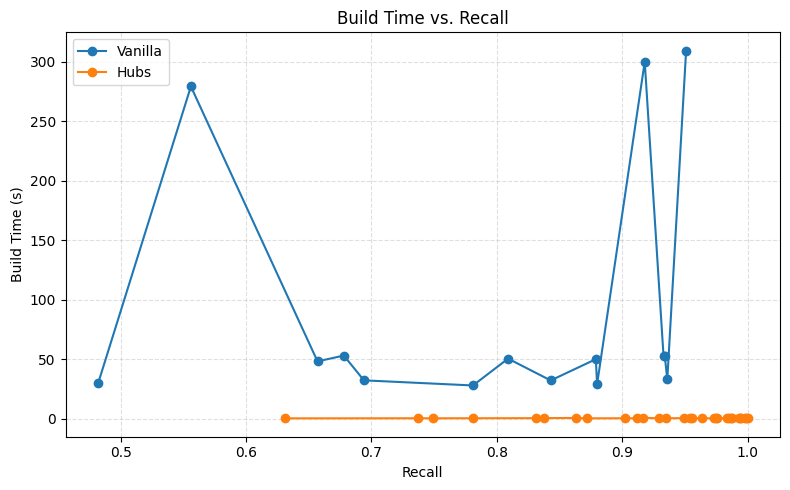

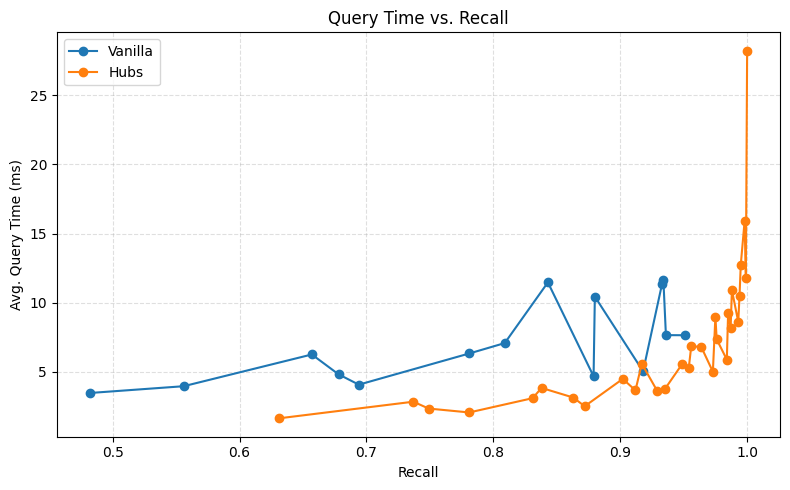

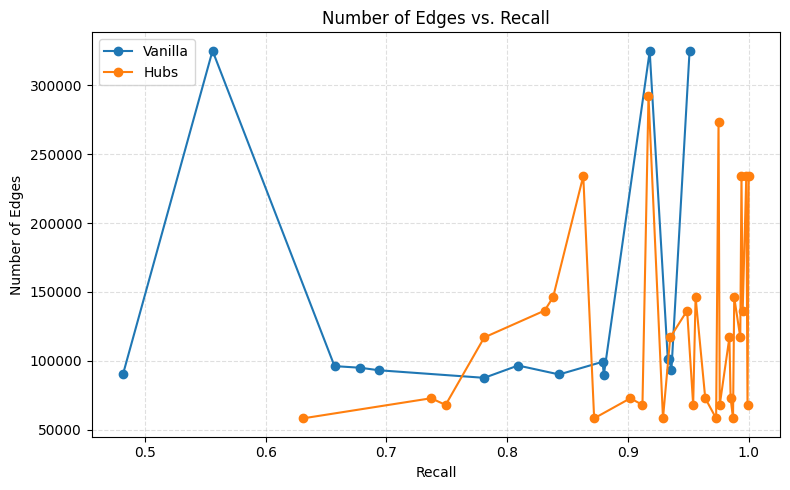

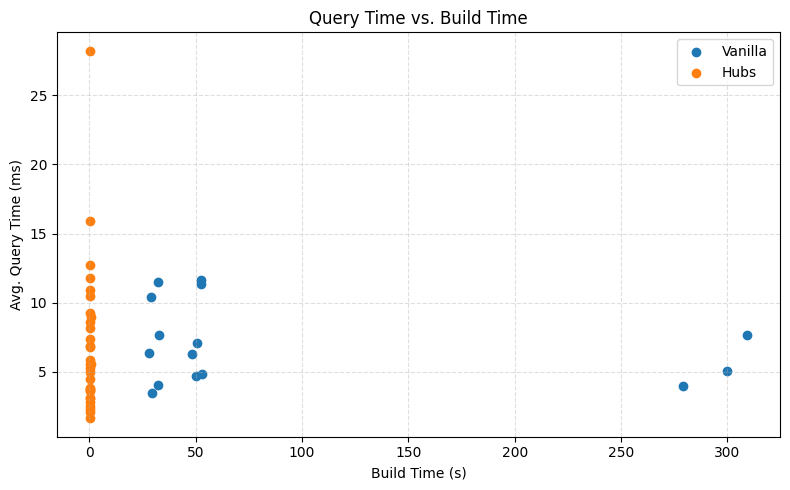

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data
vanilla_false = pd.read_csv('hnsw_grid_search_results_avg5_with_edges_new.csv')
vanilla_true  = pd.read_csv('hnsw_grid_search_results_avg5_with_edges_true_32.csv')
hubs          = pd.read_csv('supervised_hubs_hnsw_grid.csv')

# 2. Tag methods
vanilla_false['method'] = 'Vanilla'
vanilla_true['method']  = 'Vanilla'
hubs['method']          = 'Hubs'

# 3. Combine vanilla variants
vanilla = pd.concat([vanilla_false, vanilla_true], ignore_index=True)

# 4. Keep relevant columns and align recall precision
for df in (vanilla, hubs):
    df['recall'] = df['recall'].round(3)
keep_cols = ['method','recall','build_time_s','avg_query_ms','num_edges']
vanilla = vanilla[keep_cols]
hubs    = hubs[keep_cols]

# 5. Select best (minimum) build time per recall for each method
def best_by_build(df):
    idx = df.groupby('recall')['build_time_s'].idxmin()
    return df.loc[idx].sort_values('recall').reset_index(drop=True)

best_vanilla = best_by_build(vanilla)
best_hubs    = best_by_build(hubs)

# 6. Rename columns for uniformity
vanilla_best = best_vanilla.rename(columns={
    'build_time_s':'build_s',
    'avg_query_ms':'query_ms',
    'num_edges':'edges'
})
hubs_best = best_hubs.rename(columns={
    'build_time_s':'build_s',
    'avg_query_ms':'query_ms',
    'num_edges':'edges'
})


# 8. Combine for plotting
combined = pd.concat([vanilla_best, hubs_best], ignore_index=True)

# 9. Plot Build Time vs. Recall
plt.figure(figsize=(8,5))
for method in combined['method'].unique():
    subset = combined[combined['method'] == method]
    plt.plot(subset['recall'], subset['build_s'], marker='o', label=method)
plt.xlabel('Recall')
plt.ylabel('Build Time (s)')
plt.title('Build Time vs. Recall')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 10. Plot Query Time vs. Recall
plt.figure(figsize=(8,5))
for method in combined['method'].unique():
    subset = combined[combined['method'] == method]
    plt.plot(subset['recall'], subset['query_ms'], marker='o', label=method)
plt.xlabel('Recall')
plt.ylabel('Avg. Query Time (ms)')
plt.title('Query Time vs. Recall')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 11. Plot Number of Edges vs. Recall
plt.figure(figsize=(8,5))
for method in combined['method'].unique():
    subset = combined[combined['method'] == method]
    plt.plot(subset['recall'], subset['edges'], marker='o', label=method)
plt.xlabel('Recall')
plt.ylabel('Number of Edges')
plt.title('Number of Edges vs. Recall')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 12. Scatter Query Time vs. Build Time
plt.figure(figsize=(8,5))
for method in combined['method'].unique():
    subset = combined[combined['method'] == method]
    plt.scatter(subset['build_s'], subset['query_ms'], marker='o', label=method)
plt.xlabel('Build Time (s)')
plt.ylabel('Avg. Query Time (ms)')
plt.title('Query Time vs. Build Time')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


In [3]:
import pandas as pd

# 1. Load data from CSV files
vanilla_false = pd.read_csv('hnsw_grid_search_results_avg5_with_edges_new.csv')
vanilla_true  = pd.read_csv('hnsw_grid_search_results_avg5_with_edges_true_32.csv')
hubs          = pd.read_csv('supervised_hubs_hnsw_grid.csv')

# 2. Tag methods and combine vanilla variants
vanilla_false['method'] = 'Vanilla'
vanilla_true['method']  = 'Vanilla'
vanilla = pd.concat([vanilla_false, vanilla_true], ignore_index=True)
hubs['method'] = 'Hubs'

# 3. Ensure recall is numeric
vanilla['recall'] = vanilla['recall'].astype(float)
hubs['recall']    = hubs['recall'].astype(float)

# 4. Function to find best build and query times at or above a recall threshold
def best_at_threshold(df, threshold):
    df_filtered = df[df['recall'] >= threshold]
    if df_filtered.empty:
        return pd.Series({'build_time_s': None, 'avg_query_ms': None})
    best = df_filtered.loc[df_filtered['build_time_s'].idxmin()]
    return best[['build_time_s', 'avg_query_ms']]

# 5. Define recall thresholds to compare
thresholds = [0.5, 0.7, 0.8, 0.9, 0.95, 0.99, 1.0]

# 6. Build summary rows
rows = []
for t in thresholds:
    vb = best_at_threshold(vanilla, t)
    hb = best_at_threshold(hubs, t)
    rows.append({
        'Recall ≥': t,
        'Vanilla Build (s)': vb['build_time_s'],
        'Hubs Build (s)': hb['build_time_s'],
        'Vanilla Query (ms)': vb['avg_query_ms'],
        'Hubs Query (ms)': hb['avg_query_ms'],
    })

# 7. Create and display the summary DataFrame
summary = pd.DataFrame(rows)
display(summary)

,Recall ≥,Vanilla Build (s),Hubs Build (s),Vanilla Query (ms),Hubs Query (ms)
0,0.50,27.894069,0.255447,6.334012,1.648258
1,0.70,27.894069,0.259841,6.334012,8.183512
2,0.80,28.864160,0.259841,10.445163,8.183512
3,0.90,32.941341,0.259841,7.660246,8.183512
4,0.95,309.303470,0.259841,7.653548,8.183512
5,0.99,NaN,0.296697,NaN,11.796894
6,1.00,NaN,0.581623,NaN,28.212399


'Best Build and Query Times at Recall Thresholds'

,recall,vanilla_build_s,hubs_build_s,vanilla_query_ms,hubs_query_ms
0,0.50,27.894069,0.255447,6.334012,1.648258
1,0.70,27.894069,0.259841,6.334012,8.183512
2,0.80,28.864160,0.259841,10.445163,8.183512
3,0.90,32.941341,0.259841,7.660246,8.183512
4,0.95,309.303470,0.259841,7.653548,8.183512
5,0.99,NaN,0.296697,NaN,11.796894
6,1.00,NaN,0.581623,NaN,28.212399


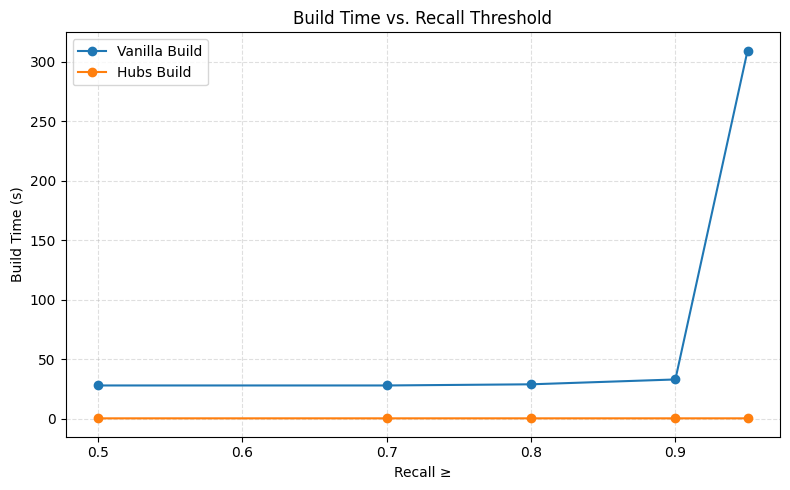

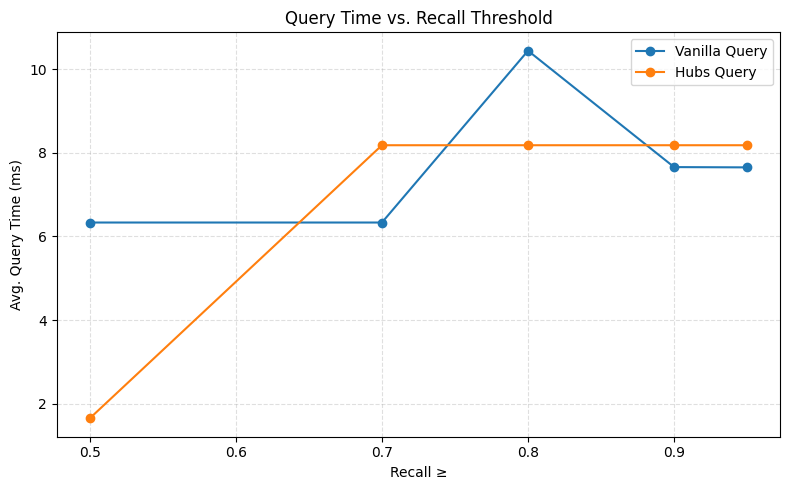

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Build DataFrame from provided summary
data = {
    'recall': [0.50, 0.70, 0.80, 0.90, 0.95, 0.99, 1.00],
    'vanilla_build_s': [27.894069, 27.894069, 28.864160, 32.941341, 309.303470, None, None],
    'hubs_build_s':    [0.255447,   0.259841,   0.259841,   0.259841,   0.259841,   0.296697,   0.581623],
    'vanilla_query_ms':[6.334012,   6.334012,   10.445163,  7.660246,   7.653548,   None,       None],
    'hubs_query_ms':   [1.648258,   8.183512,   8.183512,   8.183512,   8.183512,   11.796894,  28.212399],
}

df = pd.DataFrame(data)

# Display the table
display("Best Build and Query Times at Recall Thresholds", df)

# Plot Build Time vs. Recall ≥
plt.figure(figsize=(8, 5))
# Drop NaNs for build time lines
df_build = df[['recall', 'vanilla_build_s', 'hubs_build_s']].dropna()
plt.plot(df_build['recall'], df_build['vanilla_build_s'], marker='o', label='Vanilla Build')
plt.plot(df_build['recall'], df_build['hubs_build_s'],    marker='o', label='Hubs Build')
plt.xlabel('Recall ≥')
plt.ylabel('Build Time (s)')
plt.title('Build Time vs. Recall Threshold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Plot Query Time vs. Recall ≥
plt.figure(figsize=(8, 5))
# Drop NaNs for query time lines
df_query = df[['recall', 'vanilla_query_ms', 'hubs_query_ms']].dropna()
plt.plot(df_query['recall'], df_query['vanilla_query_ms'], marker='o', label='Vanilla Query')
plt.plot(df_query['recall'], df_query['hubs_query_ms'],    marker='o', label='Hubs Query')
plt.xlabel('Recall ≥')
plt.ylabel('Avg. Query Time (ms)')
plt.title('Query Time vs. Recall Threshold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

df.to_clipboard()


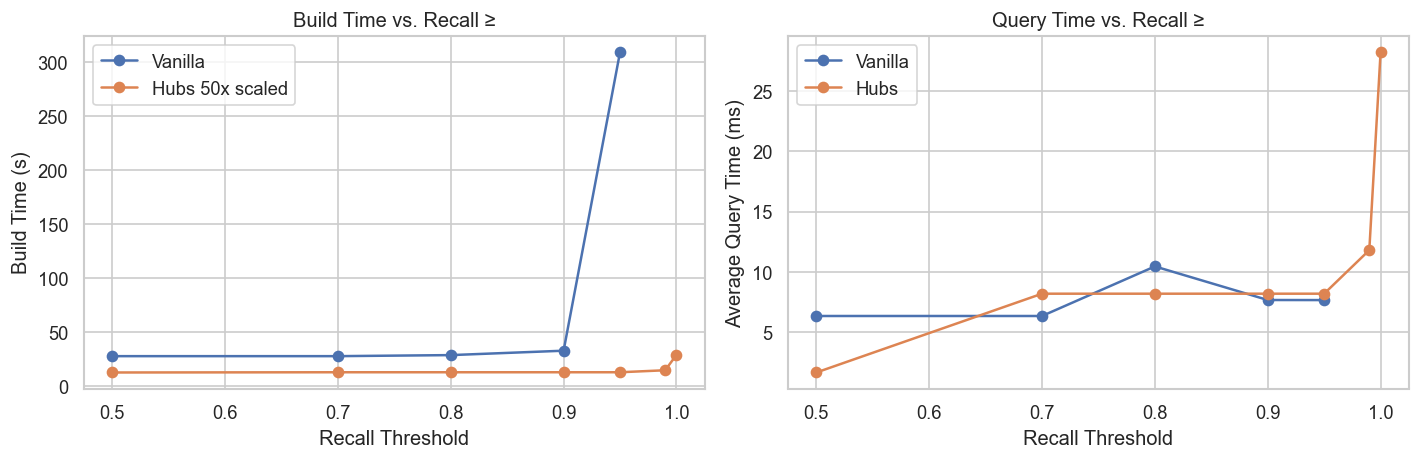

C:\Users\GSRAJA\AppData\Local\Temp\ipykernel_34724\629162274.py:52: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\GSRAJA\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


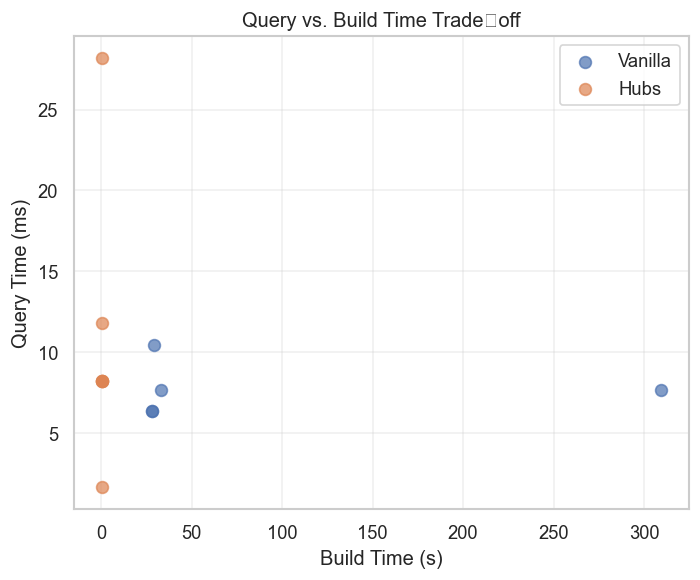

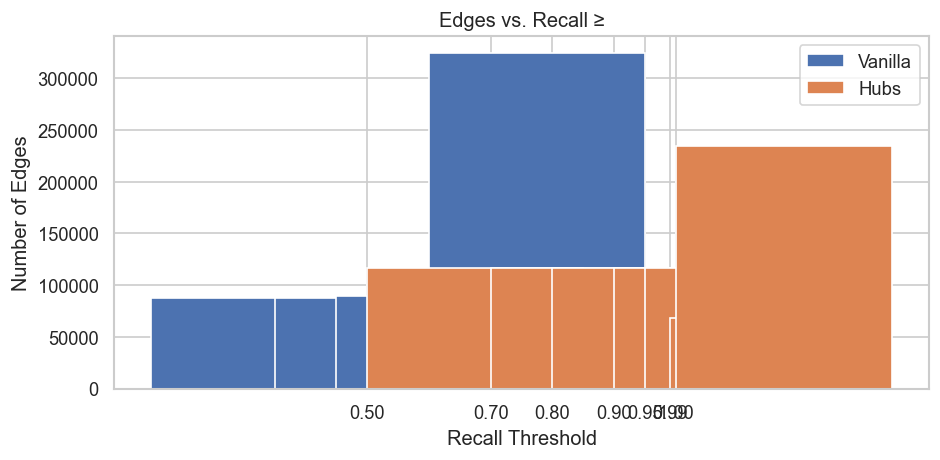

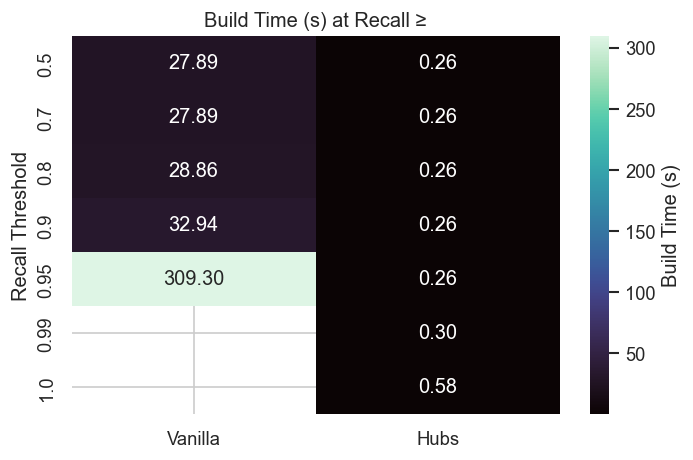

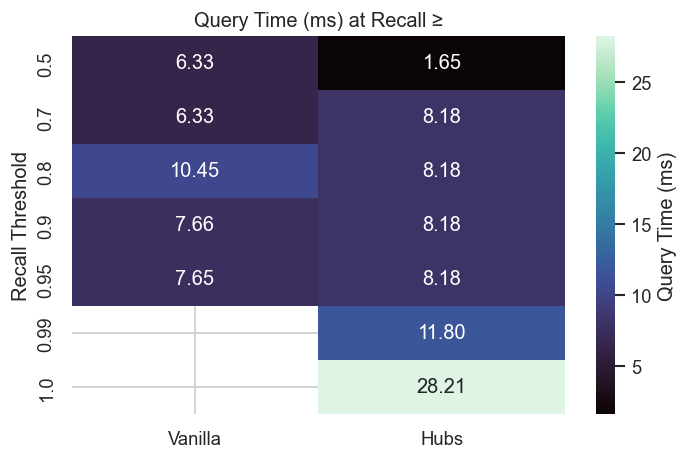

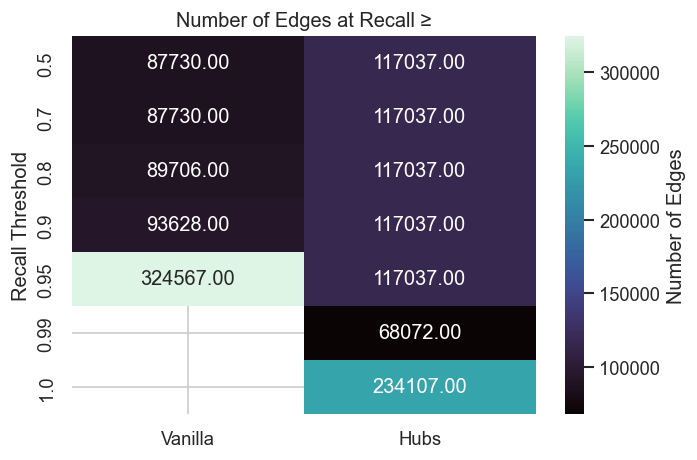

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Prepare the summary data
data = {
    'recall':          [0.50,    0.70,    0.80,    0.90,    0.95,    0.99,    1.00],
    'vanilla_build_s': [27.894069,27.894069,28.864160,32.941341,309.303470,   None,    None],
    'hubs_build_s':    [0.255447, 0.259841, 0.259841, 0.259841, 0.259841,0.296697,0.581623],
    'vanilla_query_ms':[6.334012, 6.334012,10.445163, 7.660246, 7.653548,    None,    None],
    'hubs_query_ms':   [1.648258, 8.183512, 8.183512, 8.183512, 8.183512,11.796894,28.212399],
    'vanilla_edges':   [87730,    87730,    89706,    93628,   324567,      None,    None],
    'hubs_edges':      [117037,   117037,   117037,   117037,  117037,   68072,   234107],
}
df = pd.DataFrame(data)

# 2) Global style
sns.set(style="whitegrid", font_scale=1.0)
plt.rcParams['figure.dpi'] = 120

# 3) Line plots: Build & Query time vs. Recall threshold
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

# Build time
for method in ['vanilla', 'hubs']:
    ax1.plot(df['recall'], df[f'{method}_build_s'] * (50 if method == 'hubs' else 1), marker='o', label=method.capitalize() + ("" if method == 'vanilla' else ' 50x scaled'))
ax1.set_title("Build Time vs. Recall ≥")
ax1.set_xlabel("Recall Threshold")
ax1.set_ylabel("Build Time (s)")
ax1.legend()

# Query time
for method in ['vanilla', 'hubs']:
    ax2.plot(df['recall'], df[f'{method}_query_ms'], marker='o', label=method.capitalize())
ax2.set_title("Query Time vs. Recall ≥")
ax2.set_xlabel("Recall Threshold")
ax2.set_ylabel("Average Query Time (ms)")
ax2.legend()

plt.tight_layout()
plt.show()

# 4) Scatter trade‑off: Query vs. Build Time
plt.figure(figsize=(6,5))
plt.scatter(df['vanilla_build_s'], df['vanilla_query_ms'], label='Vanilla', s=50, alpha=0.7)
plt.scatter(df['hubs_build_s'],    df['hubs_query_ms'],    label='Hubs',    s=50, alpha=0.7)
plt.xlabel("Build Time (s)")
plt.ylabel("Query Time (ms)")
plt.title("Query vs. Build Time Trade‑off")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5) Bar chart: Number of edges vs. Recall Threshold
fig, ax = plt.subplots(figsize=(8,4))
width = 0.35
x = df['recall']
ax.bar(x - width/2, df['vanilla_edges'], width, label='Vanilla')
ax.bar(x + width/2, df['hubs_edges'],    width, label='Hubs')
ax.set_xlabel("Recall Threshold")
ax.set_ylabel("Number of Edges")
ax.set_title("Edges vs. Recall ≥")
ax.set_xticks(x)
ax.legend()
plt.tight_layout()
plt.show()

# 6) Heatmaps: Build, Query, and Edges by method
metrics = [
    ('build_s',   "Build Time (s)"),
    ('query_ms',  "Query Time (ms)"),
    ('edges',     "Number of Edges"),
]
for key, label in metrics:
    # Build a pivoted DataFrame: rows=recall, cols=methods
    pivot = df.set_index('recall')[[f'vanilla_{key}', f'hubs_{key}']]
    pivot.columns = ['Vanilla', 'Hubs']
    
    plt.figure(figsize=(6,4))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="mako",
                cbar_kws={'label': label})
    plt.title(f"{label} at Recall ≥")
    plt.ylabel("Recall Threshold")
    plt.tight_layout()
    plt.show()


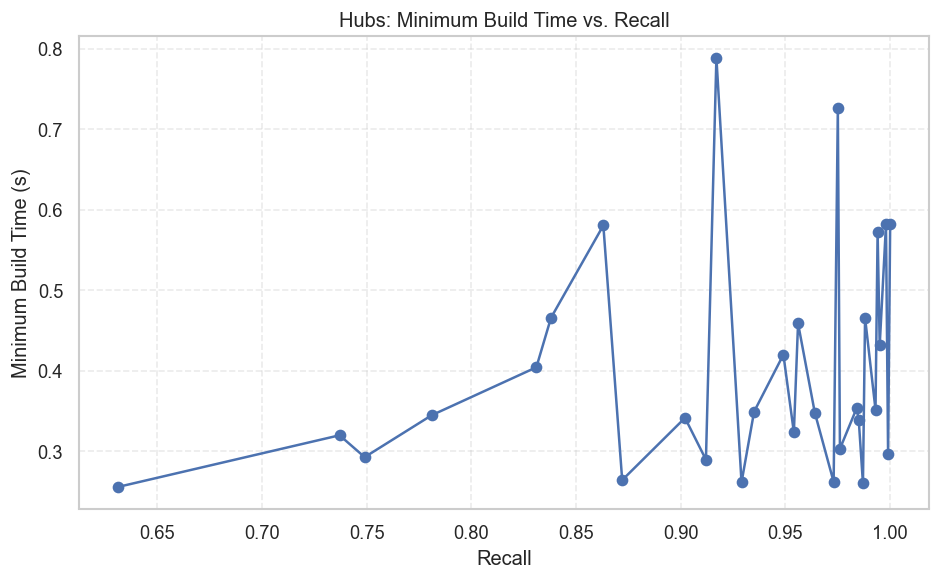

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the supervised hubs results
df = pd.read_csv('supervised_hubs_hnsw_grid.csv')

# Round recall to group properly
df['recall'] = df['recall'].round(3)

# Compute minimum build time at each recall
best_by_recall = (
    df
    .groupby('recall')['build_time_s']
    .min()
    .reset_index()
    .sort_values('recall')
)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(best_by_recall['recall'], best_by_recall['build_time_s'],
         marker='o', linestyle='-')
plt.xlabel('Recall')
plt.ylabel('Minimum Build Time (s)')
plt.title('Hubs: Minimum Build Time vs. Recall')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
